<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/AI_Project_Nikhil_Verma_N1217583.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, adjusted_rand_score, silhouette_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Loading Wheat Seeds Dataset


In [22]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt'
columns = ['area', 'perimeter', 'compactness', 'kernel_length', 'kernel_width', 'asymmetry_coeff', 'kernel_groove', 'class']
df = pd.read_csv(url, sep='\s+', names=columns, header=None)

# Data Preprocessing

In [38]:
df.head()

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coeff,kernel_groove,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [39]:
df.tail()

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coeff,kernel_groove,class
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3
209,12.30,13.34,0.8684,5.243,2.974,5.637,5.063,3


In [32]:
df.shape

(210, 8)

In [33]:
df.columns

Index(['area', 'perimeter', 'compactness', 'kernel_length', 'kernel_width',
       'asymmetry_coeff', 'kernel_groove', 'class'],
      dtype='object')

In [34]:
df.dtypes

,0
area,float64
perimeter,float64
compactness,float64
kernel_length,float64
kernel_width,float64
asymmetry_coeff,float64
kernel_groove,float64
class,int64


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area             210 non-null    float64
 1   perimeter        210 non-null    float64
 2   compactness      210 non-null    float64
 3   kernel_length    210 non-null    float64
 4   kernel_width     210 non-null    float64
 5   asymmetry_coeff  210 non-null    float64
 6   kernel_groove    210 non-null    float64
 7   class            210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [37]:
df.describe(include = 'all')

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coeff,kernel_groove,class
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [23]:
print("Missing values:\n", df.isnull().sum())
X = df.drop('class', axis=1)
y = df['class']
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

Missing values:
 area               0
perimeter          0
compactness        0
kernel_length      0
kernel_width       0
asymmetry_coeff    0
kernel_groove      0
class              0
dtype: int64


# Task 1: MLP Classifier


Task 1 - MLP Classifier Results:
Accuracy: 0.9285714285714286
Classification Report:
               precision    recall  f1-score   support

           1       0.90      0.82      0.86        11
           2       1.00      1.00      1.00        14
           3       0.89      0.94      0.91        17

    accuracy                           0.93        42
   macro avg       0.93      0.92      0.92        42
weighted avg       0.93      0.93      0.93        42



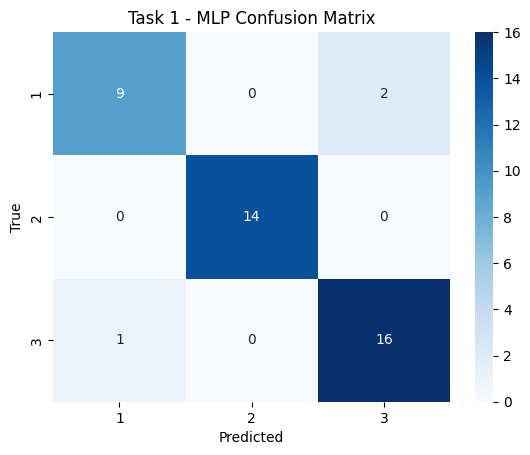

In [24]:
mlp = MLPClassifier(hidden_layer_sizes=(30, 15, 20), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)
print("\nTask 1 - MLP Classifier Results:")
print("Accuracy:", mlp.score(X_test, y_test))
print("Classification Report:\n", classification_report(y_test, mlp_pred, target_names=[str(c) for c in le.classes_]))
mlp_cm = confusion_matrix(y_test, mlp_pred)
sns.heatmap(mlp_cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Task 1 - MLP Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Task 2: Random Forest Classifier


Task 2 - Random Forest Classifier Results:
Accuracy: 0.8333333333333334
Classification Report:
               precision    recall  f1-score   support

           1       0.64      0.82      0.72        11
           2       1.00      1.00      1.00        14
           3       0.86      0.71      0.77        17

    accuracy                           0.83        42
   macro avg       0.83      0.84      0.83        42
weighted avg       0.85      0.83      0.84        42



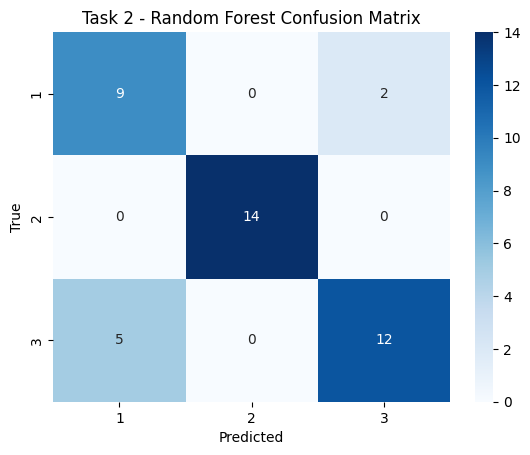

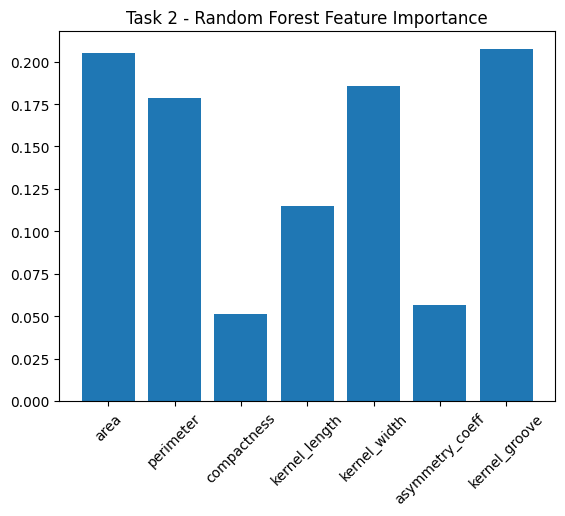

In [25]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("\nTask 2 - Random Forest Classifier Results:")
print("Accuracy:", rf.score(X_test, y_test))
print("Classification Report:\n", classification_report(y_test, rf_pred, target_names=[str(c) for c in le.classes_]))
rf_cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Task 2 - Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
plt.bar(columns[:-1], rf.feature_importances_)
plt.title('Task 2 - Random Forest Feature Importance')
plt.xticks(rotation=45)
plt.show()

# Task 3: CNN Classifier


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step

Task 3 - CNN Classifier Results:
Accuracy: 0.9047619104385376
Classification Report:
               precision    recall  f1-score   support

           1       0.77      0.91      0.83        11
           2       1.00      1.00      1.00        14
           3       0.93      0.82      0.88        17

    accuracy                           0.90        42
   macro avg       0.90      0.91      0.90        42
weighted avg       0.91      0.90      0.91        42



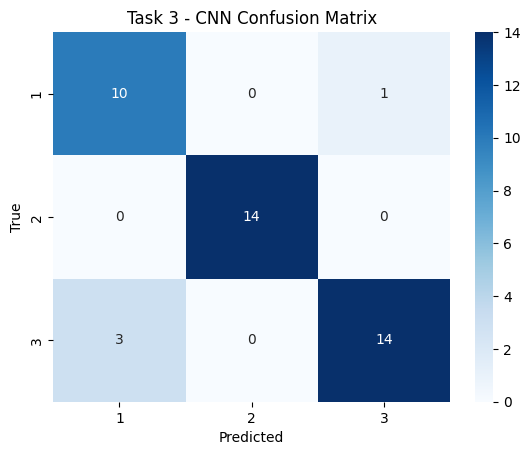

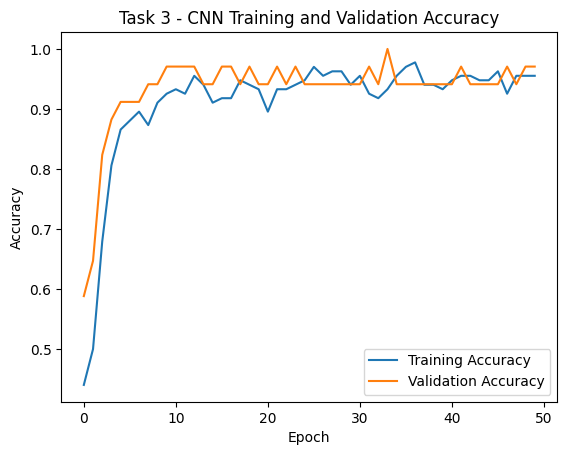

In [26]:
X_train_cnn = X_train.reshape(-1, 7, 1)
X_test_cnn = X_test.reshape(-1, 7, 1)
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)
cnn = Sequential([
    Conv1D(16, 2, activation='relu', padding='same', input_shape=(7, 1)),
    Conv1D(32, 2, activation='relu', padding='same'),
    Conv1D(64, 2, activation='relu', padding='same'),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = cnn.fit(X_train_cnn, y_train_cat, epochs=50, batch_size=16, validation_split=0.2, verbose=0)
cnn_pred = cnn.predict(X_test_cnn).argmax(axis=1)
print("\nTask 3 - CNN Classifier Results:")
print("Accuracy:", cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1])
print("Classification Report:\n", classification_report(y_test, cnn_pred, target_names=[str(c) for c in le.classes_]))
cnn_cm = confusion_matrix(y_test, cnn_pred)
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Task 3 - CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Task 3 - CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Task 4: K-means Clustering



=== Task 4: K-means Clustering ===


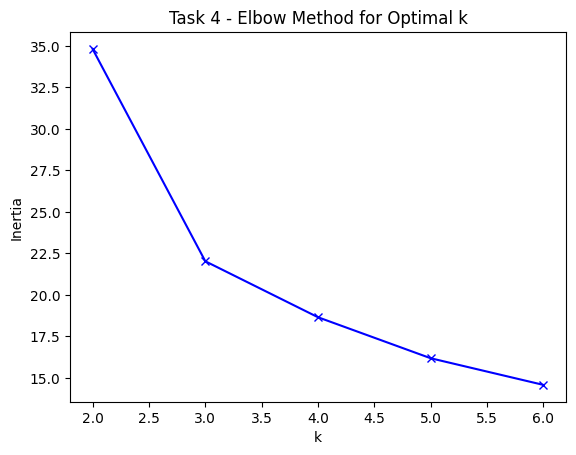

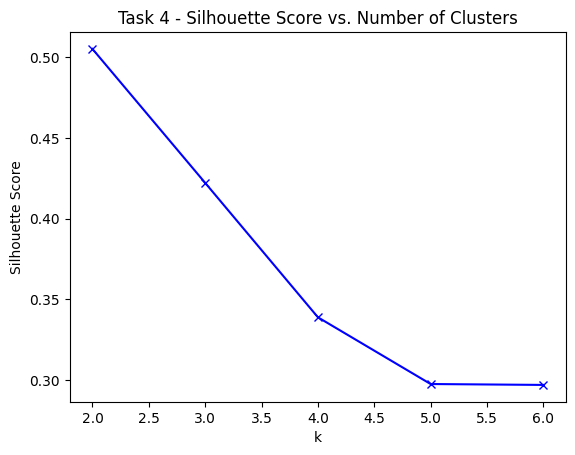


Task 4 - K-means Clustering Results:
Adjusted Rand Index: 0.7048605249026285
Silhouette Score: 0.4221052568124793


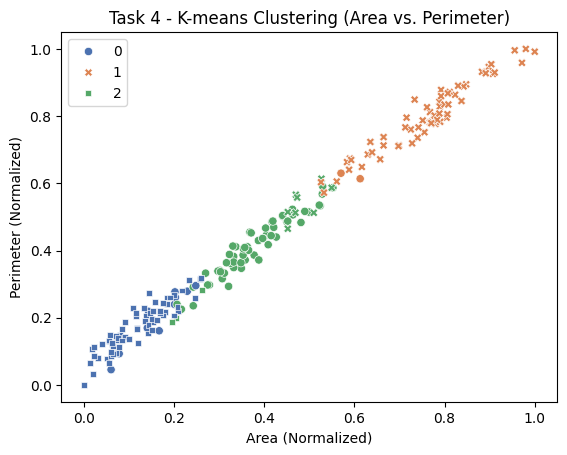

In [29]:
print("\n=== Task 4: K-means Clustering ===")
inertias = []
sil_scores = []
K = range(2, 7)
for k in K:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))
plt.plot(K, inertias, 'bx-')
plt.title('Task 4 - Elbow Method for Optimal k')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()

plt.plot(K, sil_scores, 'bx-')
plt.title('Task 4 - Silhouette Score vs. Number of Clusters')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.show()

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans.fit(X_scaled)
print("\nTask 4 - K-means Clustering Results:")
print("Adjusted Rand Index:", adjusted_rand_score(y_encoded, kmeans.labels_))
print("Silhouette Score:", silhouette_score(X_scaled, kmeans.labels_))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=kmeans.labels_, style=y_encoded, palette='deep')
plt.title('Task 4 - K-means Clustering (Area vs. Perimeter)')
plt.xlabel('Area (Normalized)')
plt.ylabel('Perimeter (Normalized)')
plt.show()